# Model Evaluation & Threshold Tuning

Notebook ini digunakan untuk melakukan evaluasi terhadap model terbaik yang telah dipilih dari proses training pipeline.

Adapun tujuan utama dari notebook ini adalah:

- Memuat (load) model terbaik hasil training
- Melakukan threshold tuning menggunakan data validasi
- Menentukan threshold optimal berdasarkan tujuan bisnis (misalnya memaksimalkan recall atau menyeimbangkan precision dan recall)
- Mengevaluasi performa akhir model menggunakan data test

Proses threshold tuning dilakukan setelah pemilihan model untuk memastikan evaluasi yang tidak bias serta menghasilkan keputusan yang lebih sesuai dengan kondisi nyata di lapangan.

In [56]:
import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath(".."))

In [57]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix
)
from src.utils.utils import ConfigManager
from sklearn.metrics import (
    precision_recall_curve, auc, 
    ConfusionMatrixDisplay, roc_curve, 
    accuracy_score
)
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Union



# Load Config

In [58]:
# Usage configuration manager
config_manager = ConfigManager('config/config.yaml')
# Load the config
config = config_manager.load_config()
config

{'best_preprocessing': 'Robust Scaler',
 'features': {'cat_nominal': ['person_home_ownership', 'loan_intent'],
  'cat_ordinal': {'cb_person_default_on_file': {'N': 0, 'Y': 1},
   'loan_grade': {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}},
  'categorical': ['person_home_ownership',
   'loan_intent',
   'loan_grade',
   'cb_person_default_on_file'],
  'numerical': ['person_age',
   'person_income',
   'person_emp_length',
   'loan_amnt',
   'loan_int_rate',
   'loan_percent_income',
   'cb_person_cred_hist_length']},
 'path': {'best_model': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/models/best_model.pkl',
  'experiments': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/models/experiments/training_log.json',
  'interim_data': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/data/interim',
  'logrob_preprocessing': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/ment

# Load Best Model

In [59]:
PATH_BEST_MODEL = config['path']['best_model']
print(PATH_BEST_MODEL)
best_model = config_manager.deserialize_data(PATH_BEST_MODEL)

/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/models/best_model.pkl


# Load Data Validation and Test

In [60]:
# Data path
valid_data_path = config['path']['valid_data_processed_pipe']
test_data_path = config['path']['test_data_processed_pipe']
# Deserialization
data_valid = config_manager.deserialize_data(valid_data_path)
data_test = config_manager.deserialize_data(test_data_path)

In [61]:
# Load best preprocessing
best_prep = config['best_preprocessing']
# split X, y
X_valid = data_valid[best_prep]['X_valid']
y_valid = data_valid[best_prep]['y_valid']

X_test = data_test[best_prep]['X_test']
y_test = data_test[best_prep]['y_test']

# Threshold Tuning 

In [62]:
y_proba = best_model.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.01, 1.01, 0.01)

results = list()

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    recall = recall_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    results.append({
        "threshold": t,
        "recall": recall,
        "precision": precision,
        "f1": f1
    })

df_thr = pd.DataFrame(results)
df_thr.sort_values(by='recall', ascending=False)

,threshold,recall,precision,f1
0,0.01,1.000000,0.217038,0.356665
1,0.02,1.000000,0.217038,0.356665
21,0.22,1.000000,0.223840,0.365800
20,0.21,1.000000,0.220800,0.361729
19,0.20,1.000000,0.218885,0.359157
...,...,...,...,...
95,0.96,0.001414,1.000000,0.002825
96,0.97,0.000000,0.000000,0.000000
97,0.98,0.000000,0.000000,0.000000
98,0.99,0.000000,0.000000,0.000000


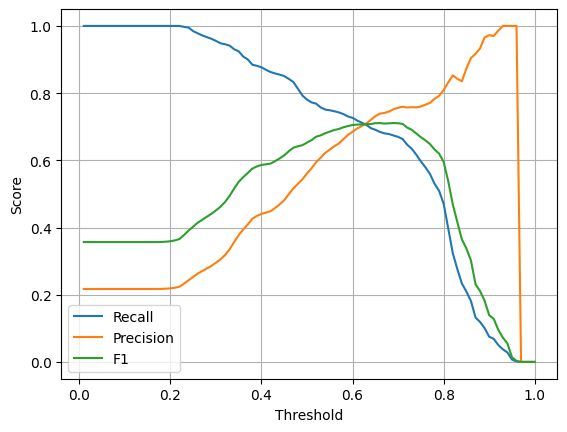

In [63]:
# Plot recall, precision dan f1
plt.plot(df_thr['threshold'], df_thr['recall'], label='Recall')
plt.plot(df_thr['threshold'], df_thr['precision'], label='Precision')
plt.plot(df_thr['threshold'], df_thr['f1'], label='F1')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

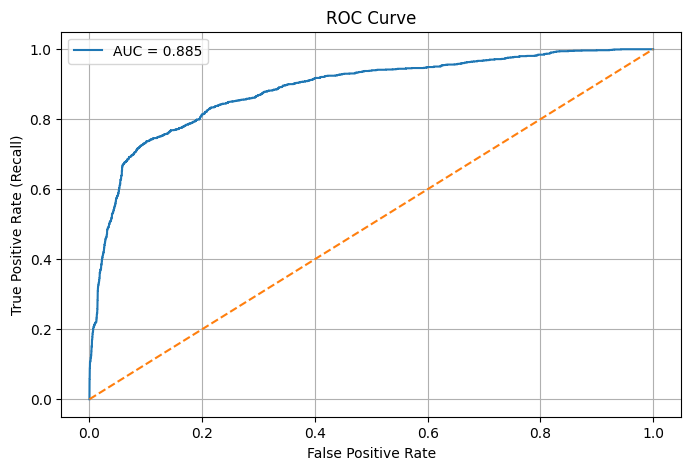

In [64]:
# hitung ROC
fpr, tpr, thresholds = roc_curve(y_valid, y_proba)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

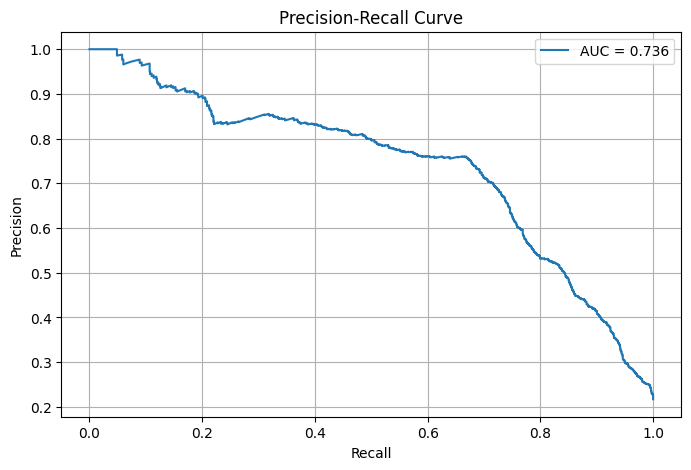

In [65]:
# Precision recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_valid, y_proba)
pr_auc = auc(recall, precision)

# plot
plt.figure(figsize=(8,5))
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

In [66]:
df_thr[df_thr['precision'] > 0.5].sort_values('recall', ascending=False)

,threshold,recall,precision,f1
46,0.47,0.833098,0.516214,0.637446
47,0.48,0.813296,0.530198,0.641920
48,0.49,0.792786,0.543647,0.644994
49,0.50,0.780764,0.560976,0.652868
50,0.51,0.772277,0.576253,0.660018
51,0.52,0.768741,0.594314,0.670367
52,0.53,0.757426,0.607487,0.674221
53,0.54,0.751061,0.622144,0.680551
54,0.55,0.748939,0.631862,0.685437
55,0.56,0.746110,0.642118,0.690219


# Business-Oriented Threshold Selection

Berdasarkan kebutuhan bisnis, kesalahan yang paling kritikal adalah false negative, yaitu ketika nasabah yang berpotensi default tidak terdeteksi oleh model.

Sebaliknya, false positive masih dapat ditoleransi, karena kasus tersebut masih dapat ditindaklanjuti melalui proses verifikasi lanjutan oleh tim bisnis.

Oleh karena itu, pemilihan threshold tidak hanya didasarkan pada nilai F1-score tertinggi, tetapi lebih menitikberatkan pada recall yang tinggi dengan precision yang masih dapat diterima.

Meskipun recall dapat dimaksimalkan hingga mendekati 100% dengan menurunkan threshold secara ekstrem, pendekatan tersebut akan menghasilkan terlalu banyak false positive yang berpotensi membebani proses operasional.

Dengan mempertimbangkan trade-off tersebut, dipilih threshold pada kisaran 0.55 – 0.6, yang memberikan keseimbangan antara:

- Kemampuan mendeteksi nasabah berisiko (recall tinggi)
- Jumlah false alarm yang masih manageable (precision cukup)

Threshold ini dinilai paling sesuai dengan tujuan bisnis untuk meminimalkan risiko kredit tanpa mengganggu efisiensi operasional.

In [67]:
# Create function to create auto selection threshold
def auto_selector_treshold(
        y_true: Union[pd.Series, np.ndarray],
        y_proba: Union[pd.Series, np.ndarray],
        strategy: str = 'recall',
        min_precision: float = None,
        thresholds: np.ndarray = np.arange(0.01, 1.0, 0.01)
) -> Tuple[float, pd.DataFrame]:
    
    # basic validation
    if len(y_true) != len(y_proba):
        raise ValueError(f'y_true and y_probab must have the same length')
    if strategy.lower() != 'recall':
        raise ValueError(f'Strategy only accepted for recall only')

    results = list()
    
    for thres in thresholds:
        y_pred = (y_proba >= thres).astype(int)

        recall = recall_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        results.append({
            'threshold': thres,
            'recall': recall,
            'precision': precision,
            'f1-score': f1
        })
        
    df = pd.DataFrame(results)

    # apply precision constraint
    if min_precision is not None:
        if not isinstance(min_precision, (int, float)):
            raise ValueError("min_precision must be numeric")

        df = df[df['precision'] >= min_precision]

        if df.empty:
            raise ValueError("No threshold satisfies the precision constraint")

    # find best recall score with min precision values
    best_threshold = df.sort_values('recall',ascending=False).iloc[0]['threshold']

    return best_threshold, df


In [68]:
best_threshold, df = auto_selector_treshold(y_valid, y_proba, strategy='RecaLL', min_precision=0.5)
display(
    best_threshold, df
)

np.float64(0.47000000000000003)

,threshold,recall,precision,f1-score
46,0.47,0.833098,0.516214,0.637446
47,0.48,0.813296,0.530198,0.641920
48,0.49,0.792786,0.543647,0.644994
49,0.50,0.780764,0.560976,0.652868
50,0.51,0.772277,0.576253,0.660018
51,0.52,0.768741,0.594314,0.670367
52,0.53,0.757426,0.607487,0.674221
53,0.54,0.751061,0.622144,0.680551
54,0.55,0.748939,0.631862,0.685437
55,0.56,0.746110,0.642118,0.690219


In [69]:
# Update Config for best threshold value
config_manager.update_config('best_threshold', float(best_threshold))

# Evaluation on Data Test

In [70]:
def evaluation_on_test_set(
        best_model: object,
        best_threshold: float,
        X_test: pd.DataFrame,
        y_test: Union[pd.Series, np.ndarray]
) -> dict:
    
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba > best_threshold).astype(int)

    cm = confusion_matrix(y_true=y_test, y_pred=y_pred, labels=best_model.classes_)
    # display cm
    fig, ax = plt.subplots(figsize=(6,5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
    plt.show()
    # extract value dari cm
    tn, fp, fn, tp = cm.ravel()
    # metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    # 
    results = {
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
    }
    return results


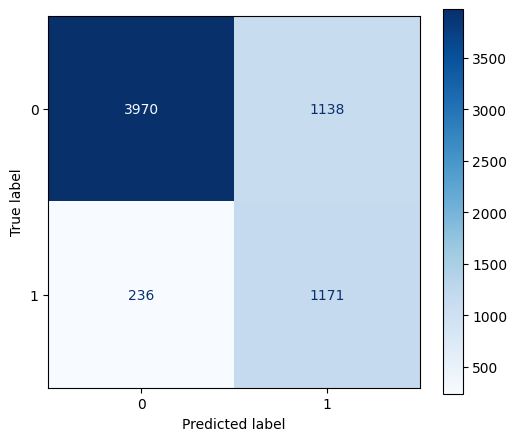

{'TP': np.int64(1171),
 'FP': np.int64(1138),
 'FN': np.int64(236),
 'TN': np.int64(3970),
 'accuracy': 0.7891020721412126,
 'precision': 0.5071459506279775,
 'recall': 0.8322672352523098,
 'f1_score': 0.6302475780409041}

In [71]:
test_results = evaluation_on_test_set(
    best_model=best_model,
    best_threshold=best_threshold,
    X_test=X_test,
    y_test=y_test
)
test_results